# 10 — Images: the dependence a linear kernel cannot see

Notebooks 01–07 live on a 1-D chain the project generates itself, where the model is correct by
construction and the only question is whether the estimator finds it. This one is the first
contact with data nobody here made: **CIFAR-10**, through a wavelet hidden Markov tree.

The structure carries over cleanly. A wavelet transform gives a tree — each coefficient at depth
$d$ has children at depth $d+1$ — and a tree is loop-free, so exact belief propagation applies
unchanged. What does *not* carry over is the assumption about how a parent constrains its child.

The result below is a negative one stated precisely, and it is more useful than a positive one
would have been: the dependence in real images sits in a coordinate the project's main kernel
family is structurally unable to represent, and making that kernel *more flexible in the wrong
coordinate* makes held-out likelihood **worse**.

## Step 1 — are the subbands even non-Gaussian?

If CIFAR wavelet coefficients were approximately Gaussian, the entire premise would not apply to
images and there would be nothing to do. So this runs first.

`excess_kurtosis_gaussian_surrogate` is the same statistic measured on a Gaussian surrogate with
matched variance — it calibrates what "zero" looks like at this sample size — and
`kurtosis_in_se` is the departure in standard errors.

In [1]:
import sys, csv, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
E23 = "../outputs/exp_23_wavelet_statistics"
E25 = "../outputs/exp_25_wavelet_generation"

sub = list(csv.DictReader(open(os.path.join(E23, "subbands.csv"))))
f = lambda r, k: float(r[k])

print(f"{'orient':>7} {'depth':>6} {'n_coef':>8} {'excess kurt':>12} {'+-se':>8} "
      f"{'surrogate':>10} {'in SE':>8}")
print("-" * 64)
for r in sub:
    print(f"{r['orientation']:>7} {r['tree_depth']:>6} {int(f(r,'n_coefficients')):>8} "
          f"{f(r,'excess_kurtosis'):>12.3f} {f(r,'excess_kurtosis_se'):>8.3f} "
          f"{f(r,'excess_kurtosis_gaussian_surrogate'):>10.3f} {f(r,'kurtosis_in_se'):>8.1f}")

worst = max(sub, key=lambda r: f(r, "kurtosis_in_se"))
print(f"\n  every subband is non-Gaussian; the strongest departure is "
      f"{f(worst,'kurtosis_in_se'):.0f} standard errors "
      f"({worst['orientation']} depth {worst['tree_depth']}).")
print("  The Gaussian surrogates sit near zero, so this is not a small-sample artefact.")

 orient  depth   n_coef  excess kurt     +-se  surrogate    in SE
----------------------------------------------------------------
     HL      0    10000        2.364    0.218     -0.053     10.8
     HL      1    40000        1.616    0.083     -0.022     19.5
     HL      2   160000        3.469    0.081      0.009     42.8
     HL      3   640000        5.305    0.066      0.002     80.0
     HL      4  2560000        7.089    0.067      0.004    105.3
     LH      0    10000        0.262    0.060     -0.058      4.4
     LH      1    40000        0.673    0.037     -0.010     18.1
     LH      2   160000        2.270    0.053      0.006     43.1
     LH      3   640000        4.109    0.050     -0.003     81.6
     LH      4  2560000        5.818    0.061     -0.003     94.8
     HH      0    10000        1.959    0.213      0.089      9.2
     HH      1    40000        1.222    0.064     -0.014     19.2
     HH      2   160000        2.687    0.061     -0.000     43.8
     HH    

## Step 2 — where the cross-scale dependence actually lives

This is the measurement the rest of the notebook turns on.

For each parent→child pair we have three numbers:

- `corr_linear` — the ordinary correlation between parent and child coefficient. This is what a
  linear autoregressive kernel models, and *all* it models.
- `std_ratio_q4_q1` — how much bigger the child's standard deviation is when the parent is in its
  top quartile versus its bottom quartile. This is magnitude dependence: big parents have big
  children, regardless of sign.
- `std_ratio_linear_ar_null` — how much magnitude dependence a linear-AR model with that
  `corr_linear` would *itself* produce. This is the control, and it is what makes the comparison
  fair rather than rhetorical.

If the measured ratio matches the null, a linear kernel is adequate. If it exceeds it, there is
dependence in the data that no linear kernel can express at any parameter setting.

In [2]:
cs = list(csv.DictReader(open(os.path.join(E23, "crossscale.csv"))))

print(f"{'orient':>7} {'pair':>8} {'corr_lin':>9} {'q4/q1':>7} {'AR null':>8} {'excess':>8}")
print("-" * 52)
for r in cs:
    print(f"{r['orientation']:>7} {'d'+r['parent_depth']+'->d'+r['child_depth']:>8} "
          f"{f(r,'corr_linear'):>9.3f} {f(r,'std_ratio_q4_q1'):>7.3f} "
          f"{f(r,'std_ratio_linear_ar_null'):>8.3f} {f(r,'std_ratio_excess_over_null'):>8.3f}")

hh = [r for r in cs if r["orientation"] == "HH"]
print("\n  The HH (diagonal) rows are the cleanest case: linear correlation between "
      f"{min(f(r,'corr_linear') for r in hh):.3f} and {max(f(r,'corr_linear') for r in hh):.3f},")
print(f"  so a linear kernel predicts a magnitude ratio of at most "
      f"{max(f(r,'std_ratio_linear_ar_null') for r in hh):.3f} -- essentially none.")
print(f"  The data has up to {max(f(r,'std_ratio_q4_q1') for r in hh):.3f}.")

 orient     pair  corr_lin   q4/q1  AR null   excess
----------------------------------------------------
     HL   d0->d1     0.182   1.355    1.048    0.307
     HL   d1->d2     0.382   1.822    1.218    0.603
     HL   d2->d3     0.392   2.577    1.232    1.345
     HL   d3->d4     0.452   3.647    1.315    2.332
     LH   d0->d1     0.352   1.341    1.184    0.157
     LH   d1->d2     0.389   1.681    1.228    0.454
     LH   d2->d3     0.416   2.377    1.263    1.114
     LH   d3->d4     0.482   3.287    1.363    1.924
     HH   d0->d1     0.039   1.342    1.002    0.340
     HH   d1->d2     0.101   1.425    1.015    0.410
     HH   d2->d3     0.100   2.050    1.014    1.036
     HH   d3->d4     0.148   2.887    1.032    1.855

  The HH (diagonal) rows are the cleanest case: linear correlation between 0.039 and 0.148,
  so a linear kernel predicts a magnitude ratio of at most 1.032 -- essentially none.
  The data has up to 2.887.


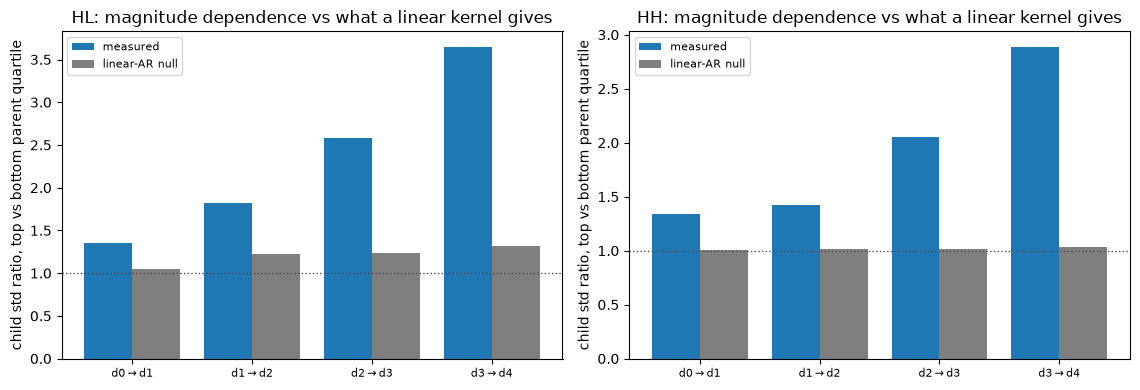

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))

for i, orient in enumerate(["HL", "HH"]):
    rows = [r for r in cs if r["orientation"] == orient]
    x = np.arange(len(rows))
    lbl = [f"d{r['parent_depth']}$\\to$d{r['child_depth']}" for r in rows]
    ax[i].bar(x - 0.2, [f(r, "std_ratio_q4_q1") for r in rows], 0.4,
              label="measured", color="C0")
    ax[i].bar(x + 0.2, [f(r, "std_ratio_linear_ar_null") for r in rows], 0.4,
              label="linear-AR null", color="C7")
    ax[i].axhline(1.0, color="0.3", ls=":", lw=1)
    ax[i].set_xticks(x); ax[i].set_xticklabels(lbl, fontsize=8)
    ax[i].set_ylabel("child std ratio, top vs bottom parent quartile")
    ax[i].set_title(f"{orient}: magnitude dependence vs what a linear kernel gives")
    ax[i].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Step 3 — the prediction, recorded before looking at the generation results

The measurement above says the cross-scale structure in CIFAR is largely **magnitude**
dependence. A kernel of the form

$$w_{\text{child}} = \rho\, w_{\text{parent}} + \varepsilon$$

represents exactly one thing about the pair: their linear correlation. Enriching $\varepsilon$ —
giving the innovation a flexible, heavy-tailed, multi-component shape — changes the *marginal*
law of the child and leaves the parent-child relationship linear.

So the prediction is: **the mixture kernel should improve the marginals and not the hierarchy.**
A kernel whose conditional *scale* depends on the parent should be needed for the hierarchy.

Three families are fitted and sampled: `gaussian` (the second-order closure), `mixture` (linear
AR, flexible innovation shape), and `scale_mixture` (conditional scale depends on the parent).

In [4]:
gen = {r["family"]: r for r in csv.DictReader(open(os.path.join(E25, "generation_summary.csv")))}
fit = {r["family"]: r for r in csv.DictReader(open(os.path.join(E25, "fit.csv")))}
FAMS = ["gaussian", "mixture", "scale_mixture"]

real_mag = f(gen["gaussian"], "mean_magnitude_excess_real")
print(f"target magnitude excess in real CIFAR: {real_mag:.4f}\n")
print(f"{'family':>15} {'heldout loglik/img':>20} {'kurt gap':>10} {'magnitude excess':>18} {'% of real':>10}")
print("-" * 78)
for fam in FAMS:
    ll = f(fit[fam], "heldout_loglik_per_image")
    kg = f(gen[fam], "kurtosis_mean_abs_gap")
    mg = f(gen[fam], "mean_magnitude_excess_generated")
    print(f"{fam:>15} {ll:>20.2f} {kg:>10.3f} {mg:>18.4f} {100*mg/real_mag:>9.1f}%")

target magnitude excess in real CIFAR: 1.0300

         family   heldout loglik/img   kurt gap   magnitude excess  % of real
------------------------------------------------------------------------------
       gaussian              -517.64      3.120            -0.0005      -0.1%
        mixture              -565.85      2.751             0.0098       0.9%
  scale_mixture              -481.78      1.418             0.2620      25.4%


## The result

**The prediction holds, and the second row is the one worth staring at.**

`mixture` reproduces $0.95\%$ of the magnitude dependence in the data — statistically
indistinguishable from the Gaussian kernel's $-0.05\%$, which is to say *none*. Its extra
flexibility bought a modest improvement in the marginal kurtosis gap ($3.12 \to 2.75$) and
nothing at all in the hierarchy, exactly as the structure of the kernel says it must.

And it is **worse on held-out likelihood than the Gaussian it replaced** — $-565.85$ against
$-517.64$, a loss of 48 nats per image. More parameters, more flexibility, worse generalisation.
That is what spending capacity in a coordinate where the data has no structure looks like: the
innovation shape is fitted to noise, and the fit pays for it.

`scale_mixture` — the kernel whose conditional scale depends on the parent — is the only one that
moves the hierarchy at all, and it is simultaneously the best on held-out likelihood. Right
structural idea.

But read the last column honestly: it captures about **25%** of the magnitude excess. The
structural diagnosis is confirmed and the problem is not solved.

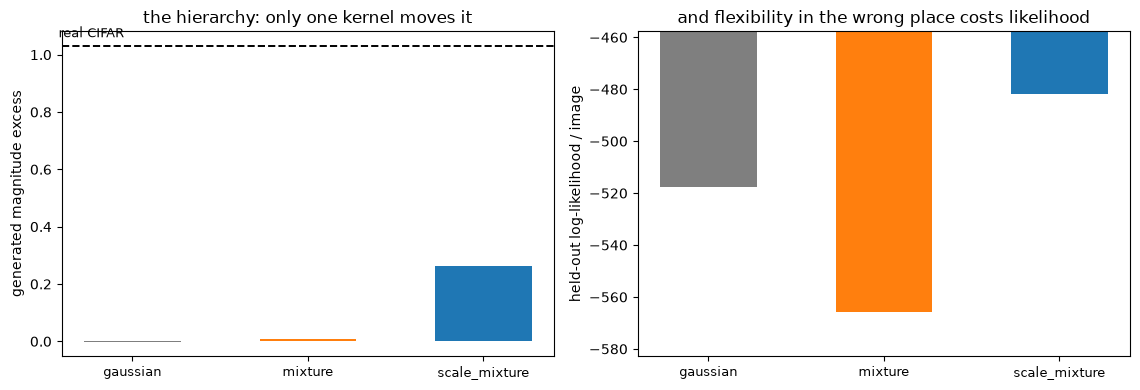

  mixture vs gaussian on held-out likelihood: -48.21 nats/image
  scale_mixture vs gaussian:                  +35.86 nats/image


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))

x = np.arange(len(FAMS))
mg = [f(gen[fm], "mean_magnitude_excess_generated") for fm in FAMS]
ax[0].bar(x, mg, 0.55, color=["C7", "C1", "C0"])
ax[0].axhline(real_mag, color="k", ls="--", lw=1.4)
ax[0].text(-0.42, real_mag * 1.03, "real CIFAR", fontsize=9)
ax[0].set_xticks(x); ax[0].set_xticklabels(FAMS, fontsize=9)
ax[0].set_ylabel("generated magnitude excess")
ax[0].set_title("the hierarchy: only one kernel moves it")

ll = [f(fit[fm], "heldout_loglik_per_image") for fm in FAMS]
ax[1].bar(x, ll, 0.55, color=["C7", "C1", "C0"])
ax[1].set_xticks(x); ax[1].set_xticklabels(FAMS, fontsize=9)
ax[1].set_ylabel("held-out log-likelihood / image")
ax[1].set_ylim(min(ll) * 1.03, max(ll) * 0.95)
ax[1].set_title("and flexibility in the wrong place costs likelihood")
plt.tight_layout(); plt.show()

print(f"  mixture vs gaussian on held-out likelihood: "
      f"{f(fit['mixture'],'heldout_loglik_per_image') - f(fit['gaussian'],'heldout_loglik_per_image'):+.2f} nats/image")
print(f"  scale_mixture vs gaussian:                  "
      f"{f(fit['scale_mixture'],'heldout_loglik_per_image') - f(fit['gaussian'],'heldout_loglik_per_image'):+.2f} nats/image")

## What to take away

1. **CIFAR wavelet subbands are strongly non-Gaussian**, by tens of standard errors against a
   matched Gaussian surrogate. The premise transfers to real images.

2. **But the cross-scale dependence is not where a linear kernel looks.** In the HH subbands the
   linear correlation is $0.04$–$0.15$, so a linear-AR model predicts almost no magnitude
   dependence, while the data shows a child-std ratio up to $2.9$ between top and bottom parent
   quartiles. This is measured against a matched null rather than asserted.

3. **Flexibility in the wrong coordinate is worse than no flexibility.** The mixture kernel
   captures $0.95\%$ of the magnitude effect and loses 48 nats per image against plain Gaussian.
   A richer innovation shape cannot repair a structurally wrong dependence, and it is not free.

4. **The right structural change works and is not sufficient.** Making the conditional scale
   depend on the parent is the only thing that moves the hierarchy, and it wins on held-out
   likelihood too — while still reaching only a quarter of the effect.

The honest one-line summary of the image extension: *the diagnosis is confirmed and the cure is
partial.* That is a more useful result for a thesis than a headline number, because it says what
to build next rather than what to claim.

*Sources: `outputs/exp_23_wavelet_statistics/{subbands,crossscale}.csv`,
`outputs/exp_25_wavelet_generation/{fit,generation_summary}.csv`. `exp_24` — the Gaussian tree
baseline in pixel coordinates — is a separate arm and had its first full run submitted on
2026-08-12; nothing here depends on it.*